# Import

In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, FunctionTransformer, MaxAbsScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.metrics import (roc_auc_score, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import PrecisionRecallDisplay
# from imblearn.over_sampling import SMOTE


# Ston.fi

## Rug

### Alice

In [31]:
x = ['10 min','1 hour','1 day','1 week','1 month','3 month']
y = [f"{i*100:.3}%" for i in [0.9757569609981235, 0.9753512197595983, 0.966069888928336, 0.9424354617842471, 0.8756403103920475, 0.7235887812547548]]
pd.DataFrame(np.array([x,y]).T, columns=['time interval for rug', 'percent for rug'])

,time interval for rug,percent for rug
0,10 min,97.6%
1,1 hour,97.5%
2,1 day,96.6%
3,1 week,94.2%
4,1 month,87.6%
5,3 month,72.4%


### TVL

In [32]:
x = ['10 min','1 hour','1 day','1 week','1 month','3 month']
y = [f"{i*100:.3}%" for i in [0.8226682100493002, 0.7281216676507285, 0.49012394645666385, 0.4225291757892659, 0.42095460815784086, 0.38911592746458806]]
pd.DataFrame(np.array([x,y]).T, columns=['time interval for rug', 'percent for rug'])

,time interval for rug,percent for rug
0,10 min,82.3%
1,1 hour,72.8%
2,1 day,49.0%
3,1 week,42.3%
4,1 month,42.1%
5,3 month,38.9%


## Dataset load

In [119]:
stonfi_df = pd.read_csv('datasets/stonfi_dataset.csv')
stonfi_df['first_buy_time'] = pd.to_datetime(stonfi_df['first_buy_time'])
stonfi_df['first_sell_time'] = pd.to_datetime(stonfi_df['first_sell_time'])
stonfi_df['pool_deployment_at'] = pd.to_datetime(stonfi_df['pool_deployment_at'])
stonfi_df['jetton_deployment_at'] = pd.to_datetime(stonfi_df['jetton_deployment_at'])
stonfi_df['min_pool_info_time'] = pd.to_datetime(stonfi_df['min_pool_info_time'])
print(f'len of stonfi_df: {len(stonfi_df)}')
stonfi_df.head()

len of stonfi_df: 19717


,token_address,project,pool_address,version,pool_deployment_at,pool_first_tx_sender,min_pool_info_time,avg_5min_lp_fee,avg_5min_protocol_fee,avg_5min_referral_fee,...,price_min_5min,price_max_hour,price_min_hour,alice_rugpull_60min,alice_rugpull_120min,alice_rugpull_180min,alice_rugpull_240min,alice_rugpull_300min,alice_rugpull_360min,alice_rugpull_420min
0,0:202DE1AE42464727DB21B1A4F8D28A9969DDFF07625B...,ston.fi,0:459279678F306C4EB776812A1CECB31ED1B6486691B2...,1,2024-08-25 08:17:02+00:00,0:49BFA028739D727B61F5B3166CCDEDA44A48D275E86F...,2024-08-25 08:17:44+00:00,0.002,0.001,0.001,...,2.010153e-02,1203.659124,2.010153e-02,0,0,0,0,0,0,0
1,0:314F893B9C3C9B29ED47103A84C942D9C125B74B42DF...,ston.fi,0:DD8C0636113A4E6BBD318C684E799E92B8298C761CEA...,2,2025-03-03 15:58:19+00:00,0:70A4118401BF8D823531A66011020565F02E05FF91AC...,2025-03-03 16:21:49+00:00,NaN,NaN,NaN,...,5.370408e-06,0.000063,3.660411e-07,22,30,30,30,32,32,32
2,0:54A3470C2F27B849EC7B179578E0378C30D34CE4D580...,ston.fi,0:402CB1C080176744B34A6E5DAC72E534D35AB3E5A883...,1,2024-04-30 13:33:04+00:00,0:10F2CAFF8775F51AAAC0C9832697781FE58BBF933D45...,2024-04-30 13:33:43+00:00,0.002,0.001,0.001,...,1.000002e-07,0.109981,1.113338e-14,0,0,0,0,0,0,0
3,0:490AE4050FFE0D361B4AAEC1E91A420D04C64BA7E770...,ston.fi,0:116347F8421AA7CB70784D4B17C407F7CA1E0925BED0...,1,2024-04-27 03:13:51+00:00,0:A648B8F768C3DD1C6D52836749FEC4975F9F74454821...,2024-04-27 03:15:03+00:00,0.002,0.001,0.001,...,6.257631e-06,0.000007,6.257631e-06,0,0,0,0,0,0,0
4,0:B1D6B0F11D029DDD7589D67C4749FB869F6361DF34C3...,ston.fi,0:F9BCDB3E8F06FAA78609F285DDB5D5218AE8D40A11F9...,1,2024-05-31 14:28:50+00:00,0:D77FC5630F1925D2831CCEB8DEC4AB842D8337863E07...,2024-05-31 14:29:02+00:00,0.002,0.001,0.001,...,6.284351e-04,0.000628,6.284351e-04,0,0,0,4,4,4,4


In [52]:
display(stonfi_df.describe(include='all'))

,token_address,project,pool_address,version,pool_deployment_at,pool_first_tx_sender,min_pool_info_time,avg_5min_lp_fee,avg_5min_protocol_fee,avg_5min_referral_fee,...,price_min_5min,price_max_hour,price_min_hour,alice_rugpull_60min,alice_rugpull_120min,alice_rugpull_180min,alice_rugpull_240min,alice_rugpull_300min,alice_rugpull_360min,alice_rugpull_420min
count,19717,19717,19717,19717.000000,18579,18579,18579,15228.000000,15228.000000,1.364000e+04,...,1.971700e+04,1.971700e+04,1.971700e+04,19717.000000,19717.000000,19717.000000,19717.000000,19717.00000,19717.000000,19717.000000
unique,19516,1,19717,NaN,NaN,8811,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,0:2F956143C461769579BAEF2E32CC2D7BC18283F40D20...,ston.fi,0:6C7C88A9D8867DDB33DCD7A5B55B4877B2221119364E...,NaN,NaN,0:779DCC815138D9500E449C5291E7F12738C23D575B53...,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,5,19717,1,NaN,NaN,1386,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,1.289091,2024-07-09 06:32:50.577103104+00:00,NaN,2024-07-09 22:43:40.388879872+00:00,0.001998,0.001001,1.000000e-03,...,1.739859e+04,3.216071e+07,1.319180e+04,29.983567,49.770553,63.598823,74.232287,83.89116,91.820967,98.177005
min,NaN,NaN,NaN,1.000000,2024-01-03 21:23:48+00:00,NaN,2024-01-03 21:25:24+00:00,0.000000,0.000200,1.000000e-03,...,2.350052e-25,2.507129e-25,9.990100e-29,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,NaN,NaN,NaN,1.000000,2024-04-13 13:03:55.500000+00:00,NaN,2024-04-13 13:41:01+00:00,0.002000,0.001000,1.000000e-03,...,1.013017e-06,5.015938e-06,2.928518e-07,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,NaN,NaN,NaN,1.000000,2024-06-03 13:02:13+00:00,NaN,2024-06-03 13:17:59+00:00,0.002000,0.001000,1.000000e-03,...,1.013017e-04,9.881256e-04,3.802412e-05,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
75%,NaN,NaN,NaN,2.000000,2024-09-30 07:59:25+00:00,NaN,2024-09-30 21:25:39+00:00,0.002000,0.001000,1.000000e-03,...,1.053057e-01,2.809225e+01,8.112881e-02,0.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000
max,NaN,NaN,NaN,2.000000,2025-03-31 20:43:04+00:00,NaN,2025-05-14 13:11:55+00:00,0.002000,0.002000,1.000000e-03,...,4.357426e+07,6.333333e+10,4.357426e+07,21168.000000,38546.000000,46242.000000,58882.000000,71820.00000,81618.000000,88518.000000


In [53]:
for token in ['0:3690254DC15B2297610CDA60744A45F2B710AA4234B89ADB630E99D79B01BD4F', '0:6CA2C99C66B0FA1478A303BA9618BC39C28FDA1FC50DE37E618BDDF98C9FD24C', '0:BDF3FA8098D129B54B4F73B5BAC5D1E1FD91EB054169C3916DFC8CCD536D1000', '0:B113A994B5024A16719F69139328EB759596C38A25F59028B146FECDC3621DFE']:
    tmp = stonfi_df[stonfi_df['token_address'] == token]['symbol'] # STON
    print(f"Drop token {token}: {tmp.iloc[0]}, len = {len(tmp)}")
    stonfi_df = stonfi_df[stonfi_df['token_address'] != token]

Drop token 0:3690254DC15B2297610CDA60744A45F2B710AA4234B89ADB630E99D79B01BD4F: STON, len = 3
Drop token 0:6CA2C99C66B0FA1478A303BA9618BC39C28FDA1FC50DE37E618BDDF98C9FD24C: STORM, len = 1
Drop token 0:BDF3FA8098D129B54B4F73B5BAC5D1E1FD91EB054169C3916DFC8CCD536D1000: tsTON, len = 1
Drop token 0:B113A994B5024A16719F69139328EB759596C38A25F59028B146FECDC3621DFE: USD₮, len = 4


In [54]:
(stonfi_df[['alice_rugpull_60min', 'alice_rugpull_120min', 'alice_rugpull_180min',
       'alice_rugpull_240min', 'alice_rugpull_300min', 'alice_rugpull_360min',
       'alice_rugpull_420min']].apply(lambda x: [1 if i == 0 else 0 for i in x])).mean().apply(lambda x: f"{x*100:.3}%")

alice_rugpull_60min     75.7%
alice_rugpull_120min    72.6%
alice_rugpull_180min    70.9%
alice_rugpull_240min    69.8%
alice_rugpull_300min    69.0%
alice_rugpull_360min    68.4%
alice_rugpull_420min    67.8%
dtype: object

In [59]:
# дропаем токены без данных
print(f'len of stonfi_df: {len(stonfi_df)}')
stonfi_df = stonfi_df[stonfi_df[['first_buy_time','first_sell_time']].apply(lambda x: min(x), axis=1).isna() == False]
stonfi_df = stonfi_df[stonfi_df['max_tvl_5min'].isna() == False]
print(f'len of stonfi_df after drop: {len(stonfi_df)}')

len of stonfi_df: 14956
len of stonfi_df after drop: 14956


In [144]:
# определяем таргет
# stonfi_df['target'] = stonfi_df['alice_rugpull_180min'].apply(lambda x: 1 if x == 0 else 0)
stonfi_df['target'] = (stonfi_df['tvl_hour'] <= stonfi_df['max_tvl_5min'] / 100).astype(int)
print(f"{float(stonfi_df['target'].sum()/len(stonfi_df)) * 100:.3}% rugpulls")
print(f'len of stonfi_df: {len(stonfi_df)}')

22.8% rugpulls
len of stonfi_df: 19717


In [126]:
stonfi_df = stonfi_df.drop(['alice_rugpull_60min', 'alice_rugpull_120min', 'alice_rugpull_180min',
       'alice_rugpull_240min', 'alice_rugpull_300min', 'alice_rugpull_360min',
       'alice_rugpull_420min'], axis=1)
print(stonfi_df.columns)

Index(['token_address', 'project', 'pool_address', 'version',
       'pool_deployment_at', 'pool_first_tx_sender', 'min_pool_info_time',
       'avg_5min_lp_fee', 'avg_5min_protocol_fee', 'avg_5min_referral_fee',
       'initial_tvl_usd', 'max_tvl_5min', 'min_tvl_5min', 'tvl_hour',
       'jetton_deployment_at', 'jetton_first_tx_sender', 'symbol', 'decimals',
       'buys_cnt', 'buys_5min', 'total_usd_buy_volume',
       'total_usd_buy_volume_5min', 'unique_buyers', 'unique_buyers_5min',
       'first_buy_time', 'initial_buy_price', 'initial_buy_price_5min',
       'sells_cnt', 'sells_5min', 'total_usd_sell_volume',
       'total_usd_sell_volume_5min', 'unique_sellers', 'unique_sellers_5min',
       'first_sell_time', 'initial_sell_price', 'initial_sell_price_5min',
       'initial_price', 'price_5min', 'price_max_5min', 'price_min_5min',
       'price_max_hour', 'price_min_hour'],
      dtype='object')


In [127]:
(stonfi_df.isna().sum() / len(stonfi_df) * 100).apply(lambda x: f"{x:.3}%")

token_address                   0.0%
project                         0.0%
pool_address                    0.0%
version                         0.0%
pool_deployment_at             5.77%
pool_first_tx_sender           5.77%
min_pool_info_time             5.77%
avg_5min_lp_fee                22.8%
avg_5min_protocol_fee          22.8%
avg_5min_referral_fee          30.8%
initial_tvl_usd                5.77%
max_tvl_5min                   22.8%
min_tvl_5min                   22.8%
tvl_hour                       13.7%
jetton_deployment_at            0.0%
jetton_first_tx_sender          0.0%
symbol                        0.538%
decimals                       2.76%
buys_cnt                        0.0%
buys_5min                       0.0%
total_usd_buy_volume            0.0%
total_usd_buy_volume_5min       0.0%
unique_buyers                   0.0%
unique_buyers_5min              0.0%
first_buy_time                 1.63%
initial_buy_price              1.63%
initial_buy_price_5min         3.66%
s

In [83]:
print(f"{float(stonfi_df['target'].sum()/len(stonfi_df)) * 100:.3}% rugpulls for 60 minutes frame ")
print(f'len of stonfi_df: {len(stonfi_df)}')

29.7% rugpulls for 60 minutes frame 
len of stonfi_df: 14956


In [84]:
stonfi_df = stonfi_df[stonfi_df['max_tvl_5min'].isna() == False]
N = 100
print(f"TVL через час меньше в 100 раз меньше максимума за 5 минут: {(stonfi_df['tvl_hour'] <= stonfi_df['max_tvl_5min'] / N).mean()*100:.3}%")
print(f"TVL через час меньше в 100 раз меньше минимума за 5 минут: {(stonfi_df['tvl_hour'] <= stonfi_df['min_tvl_5min'] / N).mean()*100:.3}%")
print(f"TVL через час меньше в 100 раз меньше начального: {(stonfi_df['tvl_hour'] <= stonfi_df['initial_tvl_usd'] / N).mean()*100:.3}%")

TVL через час меньше в 100 раз меньше максимума за 5 минут: 29.7%
TVL через час меньше в 100 раз меньше минимума за 5 минут: 26.2%
TVL через час меньше в 100 раз меньше начального: 12.3%


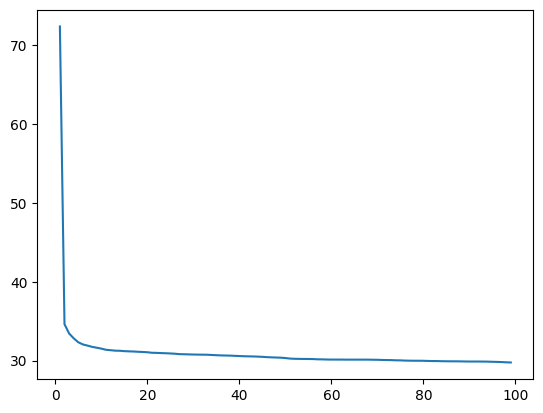

In [85]:
plt.plot(range(1,100), [(stonfi_df['tvl_hour'] <= stonfi_df['max_tvl_5min'] / i).mean()*100 for i in range(1,100)])

## Dataset prepare

In [86]:
stonfi_df['first_trade_time'] = stonfi_df[['first_buy_time','first_sell_time']].apply(lambda x: min(x), axis=1)
stonfi_df['count_tx_5min'] = stonfi_df['buys_5min'] + stonfi_df['sells_5min']
stonfi_df['buy_perc_5min'] = stonfi_df['buys_5min']/stonfi_df['count_tx_5min']
stonfi_df['sell_perc_5min'] = stonfi_df['sells_5min']/stonfi_df['count_tx_5min']
stonfi_df['total_usd_volume_5min'] = stonfi_df['total_usd_buy_volume_5min'] + stonfi_df['total_usd_sell_volume_5min']
for col in ['pool_deployment_at', 'jetton_deployment_at']:
    stonfi_df[f'{col}_month'] = pd.to_datetime(stonfi_df[col]).dt.month
stonfi_df['jetton_creation_year'] = pd.to_datetime(stonfi_df['jetton_deployment_at']).dt.year
stonfi_df['jetton_creation_trade_delta'] = (stonfi_df['first_trade_time'] - stonfi_df['jetton_deployment_at']).dt.seconds
stonfi_df['pool_creation_trade_delta'] = (stonfi_df['first_trade_time'] - stonfi_df['pool_deployment_at']).dt.seconds
stonfi_df['is_pool_creator'] = stonfi_df['pool_first_tx_sender'] == stonfi_df['jetton_first_tx_sender']


In [87]:
stonfi_df['buy_sell_ratio'] = stonfi_df['buys_5min'] / (stonfi_df['sells_5min'] + 1e-6)
stonfi_df['price_volatility'] = stonfi_df['price_max_5min'] - stonfi_df['price_min_5min']
stonfi_df['price_delta_5min'] = stonfi_df['price_5min'] - stonfi_df['initial_price']

In [88]:
stonfi_df.columns

Index(['token_address', 'project', 'pool_address', 'version',
       'pool_deployment_at', 'pool_first_tx_sender', 'min_pool_info_time',
       'avg_5min_lp_fee', 'avg_5min_protocol_fee', 'avg_5min_referral_fee',
       'initial_tvl_usd', 'max_tvl_5min', 'min_tvl_5min', 'tvl_hour',
       'jetton_deployment_at', 'jetton_first_tx_sender', 'symbol', 'decimals',
       'buys_cnt', 'buys_5min', 'total_usd_buy_volume',
       'total_usd_buy_volume_5min', 'unique_buyers', 'unique_buyers_5min',
       'first_buy_time', 'initial_buy_price', 'initial_buy_price_5min',
       'sells_cnt', 'sells_5min', 'total_usd_sell_volume',
       'total_usd_sell_volume_5min', 'unique_sellers', 'unique_sellers_5min',
       'first_sell_time', 'initial_sell_price', 'initial_sell_price_5min',
       'initial_price', 'price_5min', 'price_max_5min', 'price_min_5min',
       'price_max_hour', 'price_min_hour', 'target', 'first_trade_time',
       'count_tx_5min', 'buy_perc_5min', 'sell_perc_5min',
       'total_usd

In [89]:
# Определение типов признаков
numerical_features = [
    'buy_sell_ratio',
    'price_volatility',
    'buys_5min', # buys_cnt
    'sells_5min', # count_tx - buys_cnt
    'buy_perc_5min', # purchase percentage
    'sell_perc_5min', # sale-percentage
    'unique_buyers_5min', # unique buyers
    'unique_sellers_5min', # unique sellers
    'total_usd_volume_5min', # total eth_value
    'total_usd_buy_volume_5min', 
    'total_usd_sell_volume_5min', # sell_eth_value
    'jetton_creation_year', # creation-year
    'decimals', # decimals
    'avg_5min_lp_fee', # tax buy, tax sell
    'avg_5min_protocol_fee', # tax buy, tax sell
    'jetton_creation_trade_delta', # creation trade_delta
    'pool_creation_trade_delta', # creation pool delta
    'is_pool_creator', # is-pool creator
    'initial_tvl_usd', # Initial supply of tokens
    'initial_price', # initial price

    'initial_buy_price_5min', 
    'max_tvl_5min', 
    'min_tvl_5min',
    
    'initial_sell_price_5min', 
    'price_max_5min', 
    'price_min_5min',
    'price_delta_5min'
]
cyclical_features = [
    'pool_deployment_at_month', # creation month sin/cos
    'jetton_deployment_at_month' # creation month sin/cos
]



## Correlation analysis

C:\Users\Димас\AppData\Local\Temp\ipykernel_17188\947630115.py:15: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2 / min(k-1, r-1))
C:\Users\Димас\AppData\Local\Temp\ipykernel_17188\947630115.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


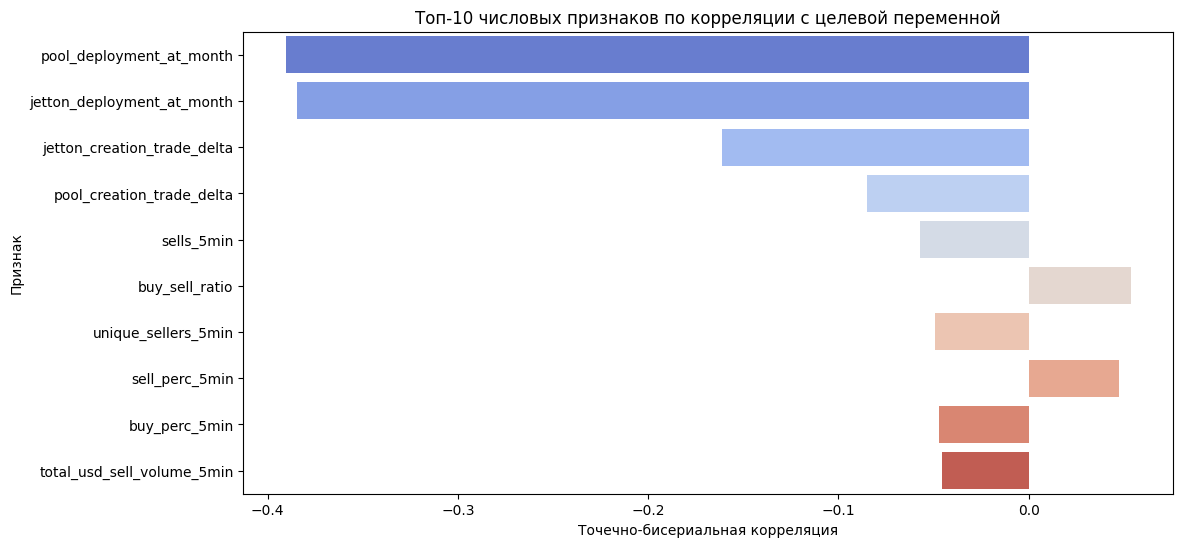

Топ числовых признаков:
                    feature  correlation      p-value
   pool_deployment_at_month    -0.390585 0.000000e+00
 jetton_deployment_at_month    -0.384497 0.000000e+00
jetton_creation_trade_delta    -0.161434 7.202565e-88
  pool_creation_trade_delta    -0.085189 1.693327e-25
                 sells_5min    -0.057135 2.701275e-12
             buy_sell_ratio     0.053801 4.584436e-11
        unique_sellers_5min    -0.049003 2.023878e-09
             sell_perc_5min     0.047302 7.142071e-09
              buy_perc_5min    -0.047302 7.142071e-09
 total_usd_sell_volume_5min    -0.045648 2.337336e-08

Топ категориальных признаков:
               feature  cramers_v
          pool_address   1.000000
         token_address   0.999573
jetton_first_tx_sender   0.916046
                symbol   0.862875
  pool_first_tx_sender   0.861429
               project        NaN


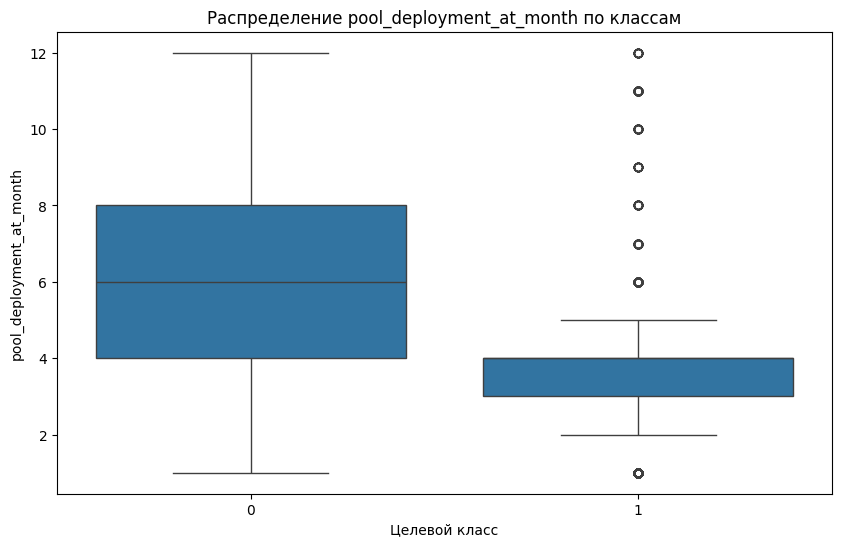

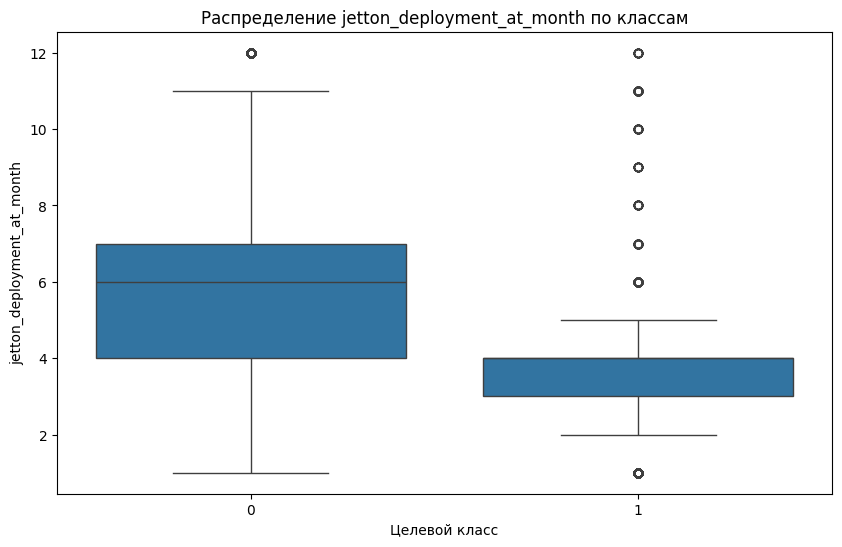

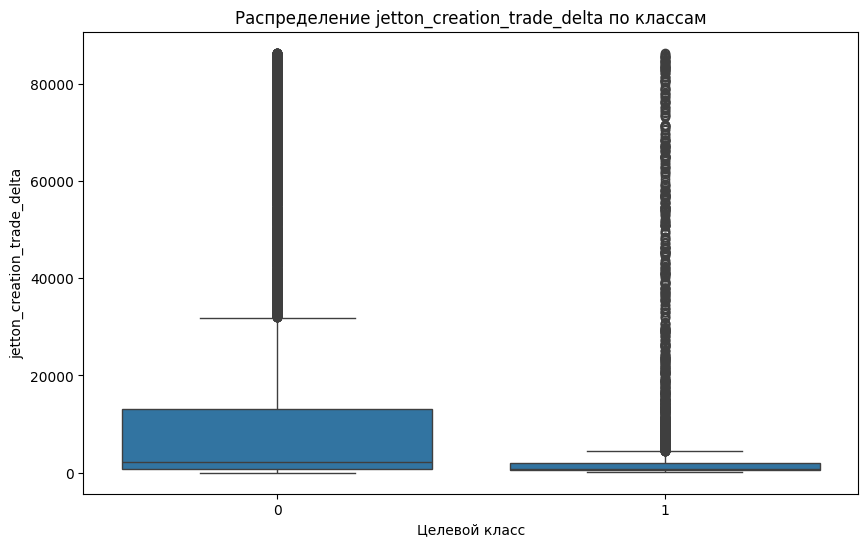

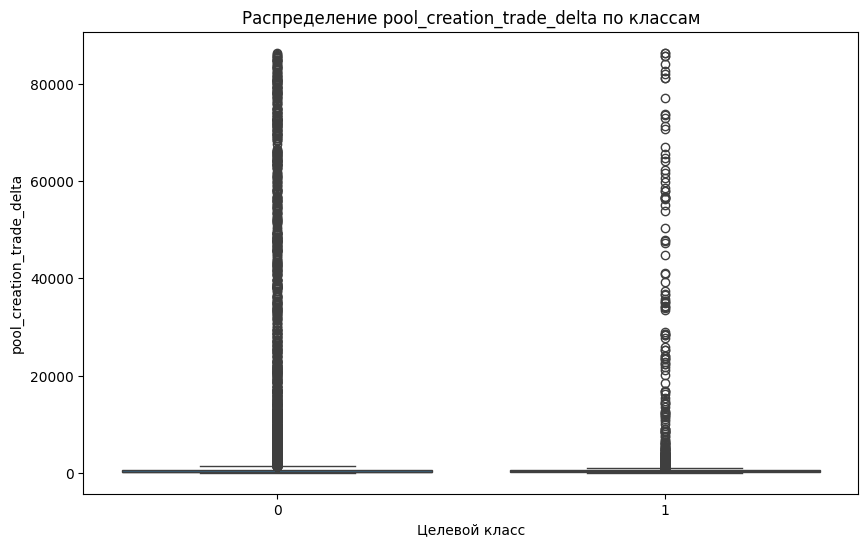

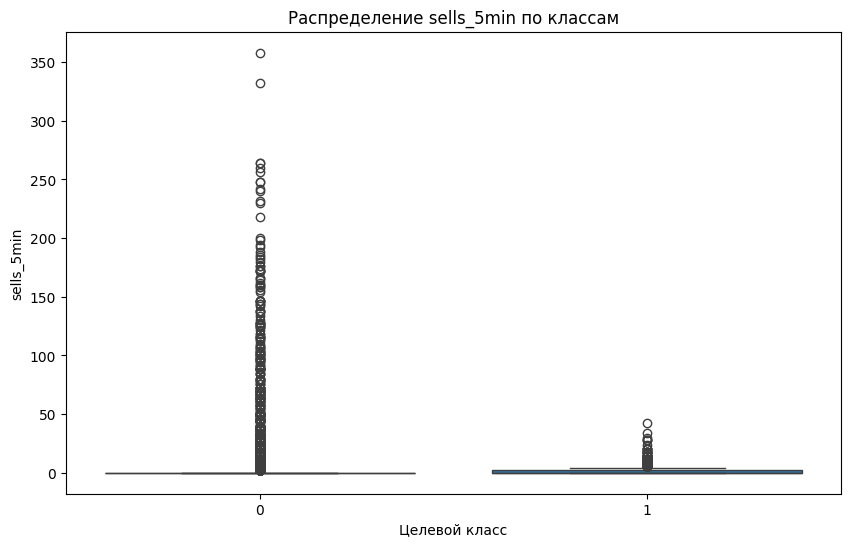

In [93]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr, chi2_contingency
from statsmodels.stats.contingency_tables import Table

def cramers_v(x, y):
    """Вычисление корреляции Крамера для категориальных признаков"""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2/n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k-1, r-1))

# Анализ для числовых признаков
numeric_features = stonfi_df[numerical_features + cyclical_features].select_dtypes(include=np.number).columns.tolist()
# numeric_features.remove('target')  # Исключаем целевую переменную

numeric_correlations = []
for feature in numeric_features:
    r, p = pointbiserialr(stonfi_df[feature], stonfi_df['target'])
    numeric_correlations.append({
        'feature': feature,
        'correlation': r,
        'p-value': p
    })
    
numeric_corr_df = pd.DataFrame(numeric_correlations).sort_values(
    by='correlation', key=abs, ascending=False)

# Анализ для категориальных признаков
categorical_features = stonfi_df.select_dtypes(include=['object', 'category']).columns.tolist()

categorical_correlations = []
for feature in categorical_features:
    v = cramers_v(stonfi_df[feature], stonfi_df['target'])
    categorical_correlations.append({
        'feature': feature,
        'cramers_v': v
    })
    
categorical_corr_df = pd.DataFrame(categorical_correlations).sort_values(
    by='cramers_v', ascending=False)

# Визуализация результатов
plt.figure(figsize=(12, 6))
sns.barplot(
    x='correlation', 
    y='feature', 
    data=numeric_corr_df.head(10),
    palette='coolwarm'
)
plt.title('Топ-10 числовых признаков по корреляции с целевой переменной')
plt.xlabel('Точечно-бисериальная корреляция')
plt.ylabel('Признак')
plt.show()

# Вывод результатов
print("Топ числовых признаков:")
print(numeric_corr_df.head(10).to_string(index=False))

print("\nТоп категориальных признаков:")
print(categorical_corr_df.head(10).to_string(index=False))

# Пример визуализации распределения для топ-признака
top_n = 5
for i in range(top_n):
    top_feature = numeric_corr_df.iloc[i]['feature']
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='target', y=top_feature, data=stonfi_df)
    plt.title(f'Распределение {top_feature} по классам')
    plt.xlabel('Целевой класс')
    plt.ylabel(top_feature)
    plt.show()


# Dedust

## Rug

### Alice

In [113]:
x = ['10 min','1 hour','1 day','1 week','1 month','3 month']
y = [f"{i*100:.3}%" for i in [0.9757569609981235, 0.9753512197595983, 0.966069888928336, 0.9424354617842471, 0.8756403103920475, 0.7235887812547548]]
pd.DataFrame(np.array([x,y]).T, columns=['time interval for rug', 'percent for rug'])

,time interval for rug,percent for rug
0,10 min,97.6%
1,1 hour,97.5%
2,1 day,96.6%
3,1 week,94.2%
4,1 month,87.6%
5,3 month,72.4%


### TVL

In [114]:
x = ['10 min','1 hour','1 day','1 week','1 month','3 month']
y = [f"{i*100:.3}%" for i in [0.9265339720519788, 0.9141651365165896, 0.6365865004039596, 0.6324095851321098, 0.6313477017825908, 0.613540944095797]]
pd.DataFrame(np.array([x,y]).T, columns=['time interval for rug', 'percent for rug'])

,time interval for rug,percent for rug
0,10 min,92.7%
1,1 hour,91.4%
2,1 day,63.7%
3,1 week,63.2%
4,1 month,63.1%
5,3 month,61.4%


## Dataset load

In [122]:
dedust_df = pd.read_csv('datasets/dedust_dataset.csv')
# обучаемся только на дедасте
dedust_df = dedust_df[dedust_df['project'] == 'dedust']
dedust_df['first_buy_time'] = pd.to_datetime(dedust_df['first_buy_time'])
dedust_df['first_sell_time'] = pd.to_datetime(dedust_df['first_sell_time'])
dedust_df['pool_deployment_at'] = pd.to_datetime(dedust_df['pool_deployment_at'])
dedust_df['jetton_deployment_at'] = pd.to_datetime(dedust_df['jetton_deployment_at'])
dedust_df['min_pool_info_time'] = pd.to_datetime(dedust_df['min_pool_info_time'])
print(f'len of dedust_df: {len(dedust_df)}')
dedust_df.head()

len of dedust_df: 33087


,token_address,project,pool_address,pool_deployment_at,pool_first_tx_sender,min_pool_info_time,avg_5min_lp_fee,avg_5min_protocol_fee,avg_5min_referral_fee,initial_tvl_usd,...,price_min_5min,price_max_hour,price_min_hour,alice_rugpull_60min,alice_rugpull_120min,alice_rugpull_180min,alice_rugpull_240min,alice_rugpull_300min,alice_rugpull_360min,alice_rugpull_420min
255,0:86D5ECAA103686ABA46E037A07EB6AF7898E8504029E...,dedust,0:FAD46A0F5CF08CE6EBDACFA706B7B5E98CF2A4DD558C...,2024-04-15 07:01:11+00:00,0:5F0564FB5F604783DB57031CE1CF668A88D4D4D6DA6D...,2024-04-15 07:01:11+00:00,0.0032,0.0008,NaN,0.000000,...,1.164366e-06,1.738069e-06,1.164366e-06,0,0,0,0,0,0,0
263,0:4018D5F2D466B7D7FCDECC91D97F789E2019D87636D6...,dedust,0:7EA08CAA959B5C49510F7B32FF0135C59DF08F74CAEA...,2024-07-14 17:53:16+00:00,0:5F0564FB5F604783DB57031CE1CF668A88D4D4D6DA6D...,2024-07-14 17:55:26+00:00,0.0020,0.0005,NaN,730.586776,...,7.265987e-07,7.265987e-07,1.649014e-12,0,0,0,0,0,0,0
448,0:4D79B547374CCFFB256B4E0273EE489EAC163FC925FD...,dedust,0:28CC42E92E074229737795D535030A57A9E795F53D89...,2024-07-18 13:46:53+00:00,0:5F0564FB5F604783DB57031CE1CF668A88D4D4D6DA6D...,2024-07-18 13:47:49+00:00,0.0020,0.0005,NaN,2021.675289,...,1.404509e-07,2.677501e-07,2.408902e-15,0,0,0,0,0,0,0
574,0:21B63CCB710108BCFAEF89F0F08204B7E0956B5EC501...,dedust,0:094E59FA99AC66E2D3E83995583C0CA47083360E0C3C...,2024-03-18 08:32:09+00:00,0:5F0564FB5F604783DB57031CE1CF668A88D4D4D6DA6D...,2024-03-18 08:32:09+00:00,0.0032,0.0008,NaN,0.000000,...,5.036747e-06,7.474889e-06,5.036747e-06,0,0,0,0,0,0,0
595,0:8881A94BD5C400C4DEDD9730C422C49E92424B6B56CA...,dedust,0:E7C1D5D95E5D595EB7F3CD15D70D3A2FD0739CAA556C...,2024-05-15 07:48:04+00:00,0:5F0564FB5F604783DB57031CE1CF668A88D4D4D6DA6D...,2024-05-15 07:54:08+00:00,0.0032,0.0008,NaN,1557.279277,...,1.546698e-08,1.955740e-08,1.546698e-08,0,0,0,0,0,0,0


In [123]:
dedust_df.describe(include='all')

,token_address,project,pool_address,pool_deployment_at,pool_first_tx_sender,min_pool_info_time,avg_5min_lp_fee,avg_5min_protocol_fee,avg_5min_referral_fee,initial_tvl_usd,...,price_min_5min,price_max_hour,price_min_hour,alice_rugpull_60min,alice_rugpull_120min,alice_rugpull_180min,alice_rugpull_240min,alice_rugpull_300min,alice_rugpull_360min,alice_rugpull_420min
count,33087,33087,33087,32501,32501,32501,30301.000000,30301.000000,0.0,32501.000000,...,3.308700e+04,3.308700e+04,3.308700e+04,33087.000000,33087.000000,33087.000000,33087.000000,33087.000000,33087.000000,33087.000000
unique,33086,1,33087,NaN,12,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,0:CF76AF318C0872B58A9F1925FC29C156211782B9FB01...,dedust,0:5705DC570757C3A8D79F990DDAD1FEDF48B7F1C0882A...,NaN,0:5F0564FB5F604783DB57031CE1CF668A88D4D4D6DA6D...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,33087,1,NaN,32409,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2024-06-15 19:57:07.854896640+00:00,NaN,2024-06-15 23:54:14.973939200+00:00,0.002676,0.000669,NaN,1633.095577,...,4.228804e+05,6.718899e+06,3.378872e+05,16.577629,26.328588,33.105570,38.416659,42.872911,46.766887,50.175175
min,NaN,NaN,NaN,2024-01-01 07:54:47+00:00,NaN,2024-01-01 07:56:54+00:00,0.000400,0.000100,NaN,0.000000,...,2.800843e-28,1.367385e-27,2.001001e-29,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,2024-04-27 16:42:43+00:00,NaN,2024-04-27 16:46:15+00:00,0.002000,0.000500,NaN,0.000000,...,1.604160e-07,1.852753e-06,1.002606e-07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,NaN,2024-06-15 11:42:53+00:00,NaN,2024-06-15 12:22:27+00:00,0.003200,0.000800,NaN,0.000000,...,4.116064e-06,1.577450e-04,2.025013e-06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,NaN,NaN,NaN,2024-07-13 17:31:14+00:00,NaN,2024-07-13 17:35:26+00:00,0.003200,0.000800,NaN,711.269743,...,1.355302e-04,1.001001e+04,1.004064e-04,0.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,NaN,NaN,NaN,2025-03-31 20:10:42+00:00,NaN,2025-05-15 12:48:35+00:00,0.003200,0.000800,NaN,479552.457246,...,2.203390e+09,9.500000e+10,2.203390e+09,5782.000000,10160.000000,16864.000000,23908.000000,29702.000000,33702.000000,36626.000000


In [124]:
(dedust_df[['alice_rugpull_60min', 'alice_rugpull_120min', 'alice_rugpull_180min',
       'alice_rugpull_240min', 'alice_rugpull_300min', 'alice_rugpull_360min',
       'alice_rugpull_420min']].apply(lambda x: [1 if i == 0 else 0 for i in x]).sum() / len(dedust_df)).apply(lambda x: f"{x*100:.3}%")

alice_rugpull_60min     76.2%
alice_rugpull_120min    73.4%
alice_rugpull_180min    72.0%
alice_rugpull_240min    71.1%
alice_rugpull_300min    70.4%
alice_rugpull_360min    69.7%
alice_rugpull_420min    69.2%
dtype: object

In [125]:
# дропаем токены без данных
print(f'len of dedust_df: {len(dedust_df)}')
dedust_df = dedust_df[dedust_df[['first_buy_time','first_sell_time']].apply(lambda x: min(x), axis=1).isna() == False]
dedust_df = dedust_df[dedust_df['max_tvl_5min'].isna() == False]
print(f'len of dedust_df after drop: {len(dedust_df)}')

len of dedust_df: 33087
len of dedust_df after drop: 30212


In [143]:
# определяем таргет
# dedust_df['target'] = dedust_df['alice_rugpull_180min'].apply(lambda x: 1 if x == 0 else 0)
dedust_df['target'] = (dedust_df['tvl_hour'] / 100 <= dedust_df['max_tvl_5min'] ).astype(int)
print(f"{float(dedust_df['target'].sum()/len(dedust_df)) * 100:.3}% rugpulls")
print(f'len of dedust_df: {len(dedust_df)}')

99.5% rugpulls
len of dedust_df: 30212


In [130]:
dedust_df = dedust_df.drop(['pool_address', 'avg_5min_referral_fee', 'alice_rugpull_60min', 'alice_rugpull_120min', 'alice_rugpull_180min',
       'alice_rugpull_240min', 'alice_rugpull_300min', 'alice_rugpull_360min',
       'alice_rugpull_420min'], axis=1)
print(dedust_df.columns)

Index(['token_address', 'project', 'pool_deployment_at',
       'pool_first_tx_sender', 'min_pool_info_time', 'avg_5min_lp_fee',
       'avg_5min_protocol_fee', 'initial_tvl_usd', 'max_tvl_5min',
       'min_tvl_5min', 'tvl_hour', 'jetton_deployment_at',
       'jetton_first_tx_sender', 'symbol', 'decimals', 'buys_cnt', 'buys_5min',
       'total_usd_buy_volume', 'total_usd_buy_volume_5min', 'unique_buyers',
       'unique_buyers_5min', 'first_buy_time', 'initial_buy_price',
       'initial_buy_price_5min', 'sells_cnt', 'sells_5min',
       'total_usd_sell_volume', 'total_usd_sell_volume_5min', 'unique_sellers',
       'unique_sellers_5min', 'first_sell_time', 'initial_sell_price',
       'initial_sell_price_5min', 'initial_price', 'price_5min',
       'price_max_5min', 'price_min_5min', 'price_max_hour', 'price_min_hour',
       'target'],
      dtype='object')


In [131]:
(dedust_df.isna().sum() / len(dedust_df) * 100).apply(lambda x: f"{x:.3}%")

token_address                    0.0%
project                          0.0%
pool_deployment_at               0.0%
pool_first_tx_sender             0.0%
min_pool_info_time               0.0%
avg_5min_lp_fee                  0.0%
avg_5min_protocol_fee            0.0%
initial_tvl_usd                  0.0%
max_tvl_5min                     0.0%
min_tvl_5min                     0.0%
tvl_hour                         0.0%
jetton_deployment_at             0.0%
jetton_first_tx_sender           0.0%
symbol                        0.0563%
decimals                        3.36%
buys_cnt                         0.0%
buys_5min                        0.0%
total_usd_buy_volume             0.0%
total_usd_buy_volume_5min        0.0%
unique_buyers                    0.0%
unique_buyers_5min               0.0%
first_buy_time                   0.0%
initial_buy_price                0.0%
initial_buy_price_5min         0.381%
sells_cnt                        0.0%
sells_5min                       0.0%
total_usd_se

## Dataset prepare

In [133]:
dedust_df['first_trade_time'] = dedust_df[['first_buy_time','first_sell_time']].apply(lambda x: min(x), axis=1)
dedust_df['count_tx_5min'] = dedust_df['buys_5min'] + dedust_df['sells_5min']
dedust_df['buy_perc_5min'] = dedust_df['buys_5min']/dedust_df['count_tx_5min']
dedust_df['sell_perc_5min'] = dedust_df['sells_5min']/dedust_df['count_tx_5min']
dedust_df['total_usd_volume_5min'] = dedust_df['total_usd_buy_volume_5min'] + dedust_df['total_usd_sell_volume_5min']
for col in ['pool_deployment_at', 'jetton_deployment_at']:
    dedust_df[f'{col}_month'] = pd.to_datetime(dedust_df[col]).dt.month
dedust_df['jetton_creation_year'] = pd.to_datetime(dedust_df['jetton_deployment_at']).dt.year
dedust_df['jetton_creation_trade_delta'] = (dedust_df['first_trade_time'] - dedust_df['jetton_deployment_at']).dt.seconds
dedust_df['pool_creation_trade_delta'] = (dedust_df['first_trade_time'] - dedust_df['pool_deployment_at']).dt.seconds
dedust_df['is_pool_creator'] = dedust_df['pool_first_tx_sender'] == dedust_df['jetton_first_tx_sender']


In [136]:
dedust_df['buy_sell_ratio'] = dedust_df['buys_5min'] / (dedust_df['sells_5min'] + 1e-6)
dedust_df['price_volatility'] = dedust_df['price_max_5min'] - dedust_df['price_min_5min']
dedust_df['price_delta_5min'] = dedust_df['price_5min'] - dedust_df['initial_price']

# Learn

In [137]:

# Функции для циклического кодирования
def sin_transformer(period):
    return FunctionTransformer(lambda x: np.sin(x / period * 2 * np.pi))

def cos_transformer(period):
    return FunctionTransformer(lambda x: np.cos(x / period * 2 * np.pi))

## define columns

In [138]:
# Определение типов признаков
categorical_features = [
    'project'
]
numerical_features = [
    'buy_sell_ratio',
    'price_volatility',
    'buys_5min', # buys_cnt
    'sells_5min', # count_tx - buys_cnt
    'buy_perc_5min', # purchase percentage
    'sell_perc_5min', # sale-percentage
    'unique_buyers_5min', # unique buyers
    'unique_sellers_5min', # unique sellers
    'total_usd_volume_5min', # total eth_value
    'total_usd_buy_volume_5min', 
    'total_usd_sell_volume_5min', # sell_eth_value
    'jetton_creation_year', # creation-year
    'decimals', # decimals
    'avg_5min_lp_fee', # tax buy, tax sell
    'avg_5min_protocol_fee', # tax buy, tax sell
    'jetton_creation_trade_delta', # creation trade_delta
    'pool_creation_trade_delta', # creation pool delta
    'is_pool_creator', # is-pool creator
    'initial_tvl_usd', # Initial supply of tokens
    'initial_price', # initial price

    'initial_buy_price_5min', 
    'max_tvl_5min', 
    'min_tvl_5min',
    
    'initial_sell_price_5min', 
    'price_max_5min', 
    'price_min_5min',
    'price_delta_5min'
]
cyclical_features = [
    'pool_deployment_at_month', # creation month sin/cos
    'jetton_deployment_at_month' # creation month sin/cos
]



## learn

## Data prepare

In [139]:
# Разделение данных

X = dedust_df[numerical_features + cyclical_features]
y = dedust_df['target']
# X = stonfi_df[numerical_features + cyclical_features]
# y = stonfi_df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [140]:
# Конвейер предобработки
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    # ('scaler', MaxAbsScaler())
    # ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        # ('cat', categorical_transformer, categorical_features),
        ('cycl_sin', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('sin', sin_transformer(12))
        ]), cyclical_features),
        ('cycl_cos', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('cos', cos_transformer(12))
        ]), cyclical_features)
    ]
)
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['buy_sell_ratio', 'price_volatility',
                                  'buys_5min', 'sells_5min', 'buy_perc_5min',
                                  'sell_perc_5min', 'unique_buyers_5min',
                                  'unique_sellers_5min',
                                  'total_usd_volume_5min',
                                  'total_usd_buy_volume_5min',
                                  'total_usd_sell_volume_5min',
                                  'jetton_creation_year', 'decim...
                                                  FunctionTransformer(func=<function sin_transformer.<locals>.<lambda> at 0x00000177FE643EB0>))]),
                                 ['pool_deployment_at_month',
                                  'jetton_deployment_at_month']),
                                ('cycl_cos',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('cos',
                                                  FunctionTransformer(func=<function cos_transformer.<locals>.<lambda> at 0x00000177FE642560>))]),
                                 ['pool_deployment_at_month',
                                  'jetton_deployment_at_month'])])

In [141]:
# Настройка моделей и гиперпараметров
models_config = {
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1, bootstrap=True),
        'params': {
            'classifier__n_estimators': [200, 300],
            'classifier__max_depth': [None, 15, 20],
            'classifier__min_samples_split': [2, 5],
            'classifier__max_features': ['sqrt', 0.8],
            # 'classifier__bootstrap': [True, False],
            'classifier__class_weight': [{0: 0.3, 1: 0.7}, 'balanced']
        }
    },
    'XGBoost': {
        'model': XGBClassifier(
            objective='binary:logistic', #
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1
        ),
        'params': {
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__max_depth': [3, 5, 7, 10],
            'classifier__subsample': [0.8, 1.0],
            'classifier__colsample_bytree': [0.8, 1.0],
            'classifier__gamma': [0, 1],
            'classifier__scale_pos_weight': [0.7/0.3, 0.83, 0.3/0.7]
        }
    },
    'GradientBoosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__n_estimators': [200, 300],
            'classifier__max_depth': [3, 5, 10],
            'classifier__min_samples_split': [2, 5],
            'classifier__max_features': ['sqrt', 0.8],
            'classifier__subsample': [0.8, 1.0],
            'classifier__loss': ['log_loss', 'exponential']
        }
    },
    'AdaBoost': {
        'model': AdaBoostClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__learning_rate': [0.01, 0.5, 1.0]
        }
    },
    'DecisionTree': {
        'model': DecisionTreeClassifier(class_weight='balanced', random_state=42),
        'params': {
            'classifier__max_depth': [None, 5, 10, 15, 20],
            'classifier__min_samples_split': [2, 5],
            'classifier__max_features': ['sqrt', 0.8]
        }
    },
    'ExtremeGradientBoosting': {
        'model': XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            scale_pos_weight=0.82,
            random_state=42,
            n_jobs=-1
        ),
        'params': {
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__max_depth': [5, 7, 10],
            'classifier__subsample': [0.8, 1.0],
            'classifier__colsample_bytree': [0.8, 1.0],
            'classifier__gamma': [0, 1, 5],
            'classifier__reg_alpha': [0, 0.1, 1],
            'classifier__reg_lambda': [1, 1.5, 2]
        }
    }
}

# Обучение и оптимизация
results = {}
for model_name, config in models_config.items():
    print(f"Fit {model_name}")
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', config['model'])
    ])
    
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=config['params'],
        scoring='roc_auc',
        cv=StratifiedKFold(n_splits=3),
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]
    
    results[model_name] = {
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_,
        'test_auc': roc_auc_score(y_test, y_proba),
        'report': classification_report(y_test, y_pred),
        'model': best_model
    }

Fit RandomForest
Fitting 3 folds for each of 48 candidates, totalling 144 fits
Fit XGBoost
Fitting 3 folds for each of 192 candidates, totalling 576 fits
Fit GradientBoosting
Fitting 3 folds for each of 192 candidates, totalling 576 fits
Fit AdaBoost
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Fit DecisionTree
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Fit ExtremeGradientBoosting
Fitting 3 folds for each of 648 candidates, totalling 1944 fits


Model: RandomForest
Best CV AUC: 0.8265
Test AUC: 0.8366
Best Parameters:
  classifier__class_weight: balanced
  classifier__max_depth: 20
  classifier__max_features: sqrt
  classifier__min_samples_split: 5
  classifier__n_estimators: 300
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.68      0.71      2638
           1       0.77      0.83      0.80      3405

    accuracy                           0.76      6043
   macro avg       0.76      0.75      0.75      6043
weighted avg       0.76      0.76      0.76      6043



Model: XGBoost
Best CV AUC: 0.8298
Test AUC: 0.8400
Best Parameters:
  classifier__colsample_bytree: 0.8
  classifier__gamma: 1
  classifier__learning_rate: 0.05
  classifier__max_depth: 10
  classifier__scale_pos_weight: 0.4285714285714286
  classifier__subsample: 0.8
Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.84      0.72      2638
       

<Figure size 1000x600 with 0 Axes>

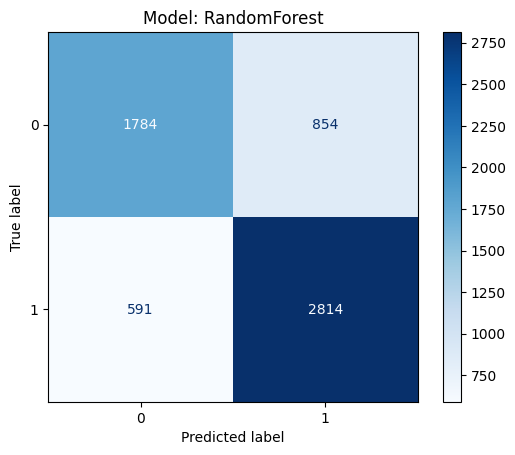

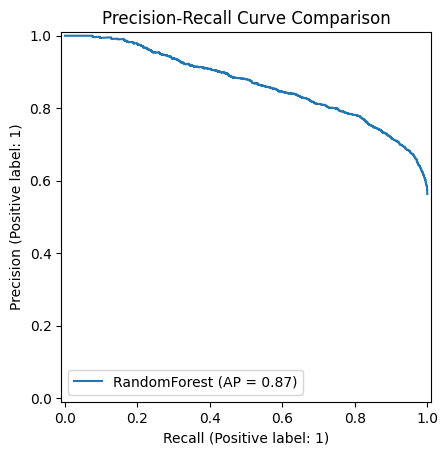

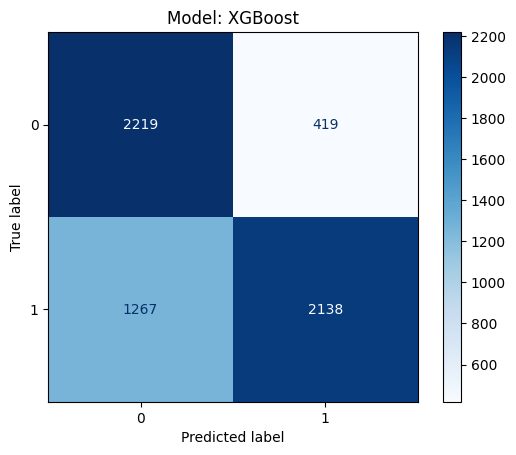

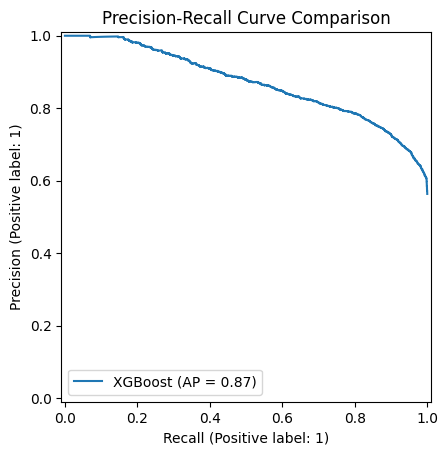

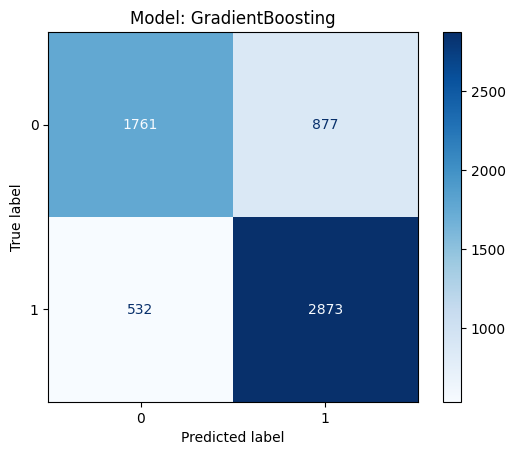

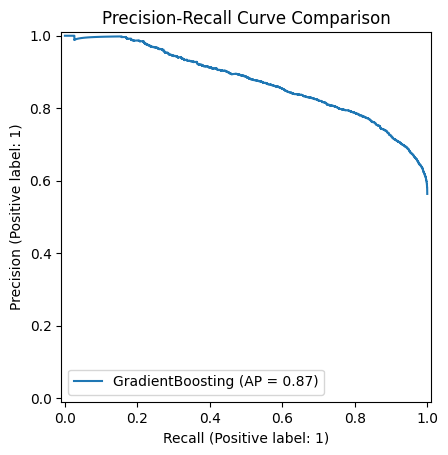

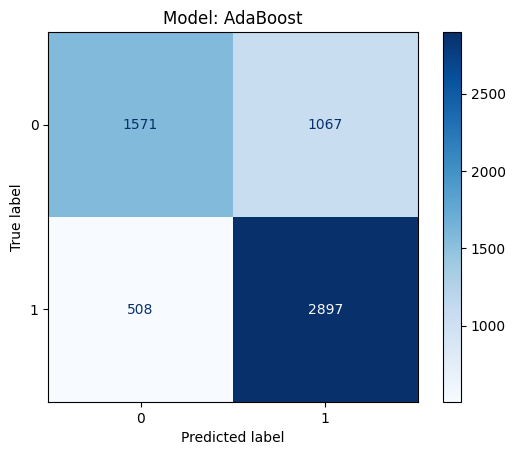

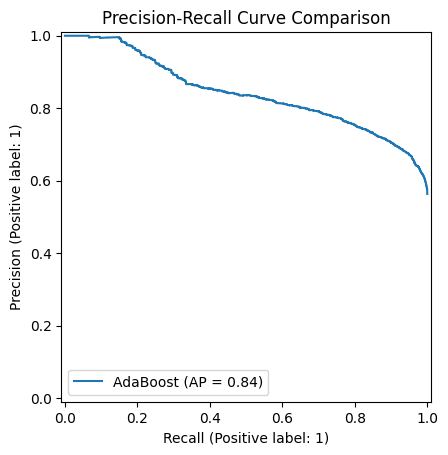

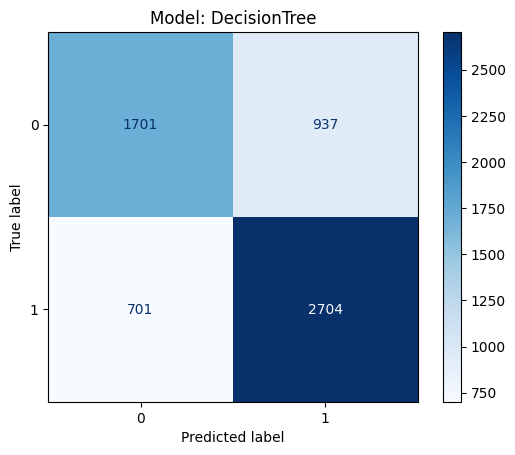

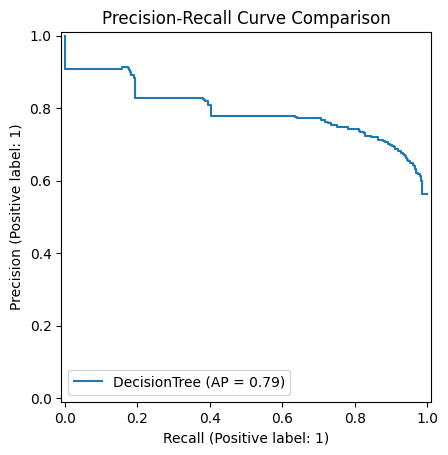

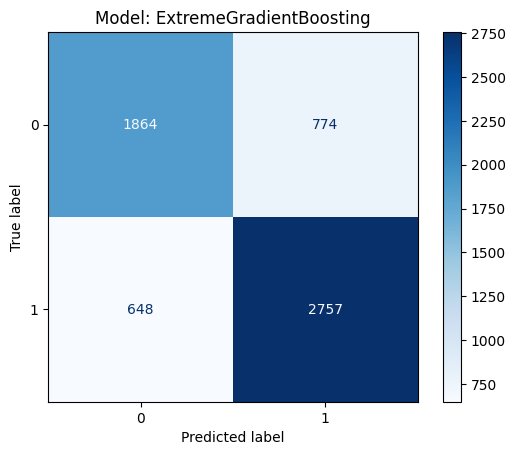

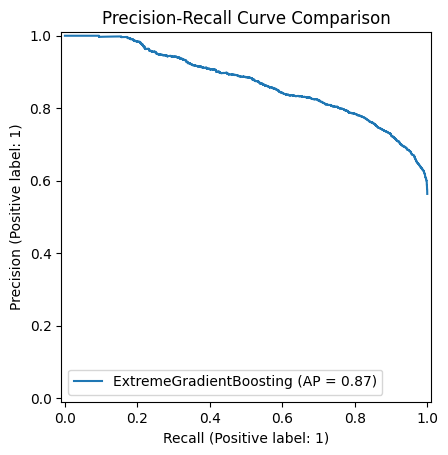

In [142]:

# Анализ результатов
for model_name, metrics in results.items():
    print(f"Model: {model_name}")
    print(f"Best CV AUC: {metrics['best_score']:.4f}")
    print(f"Test AUC: {metrics['test_auc']:.4f}")
    print("Best Parameters:")
    for param, value in metrics['best_params'].items():
        print(f"  {param}: {value}")
    print("Classification Report:")
    print(metrics['report'])
    print("\n" + "="*80 + "\n")

# Визуализация лучшей модели
best_model_name = max(results, key=lambda x: results[x]['test_auc'])
print(F"BEST MODEL WITH {max([results[x]['test_auc'] for x in results]):.3} AUC IS {best_model_name}")

plt.figure(figsize=(10, 6))
for name, res in results.items():
    cm = confusion_matrix(y_test, res['model'].predict(X_test))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f'Model: {name}')
    plt.show()
    PrecisionRecallDisplay.from_estimator(
        res['model'], X_test, y_test, name=name
    )
    plt.title('Precision-Recall Curve Comparison')
    plt.show()


## Feature visualize

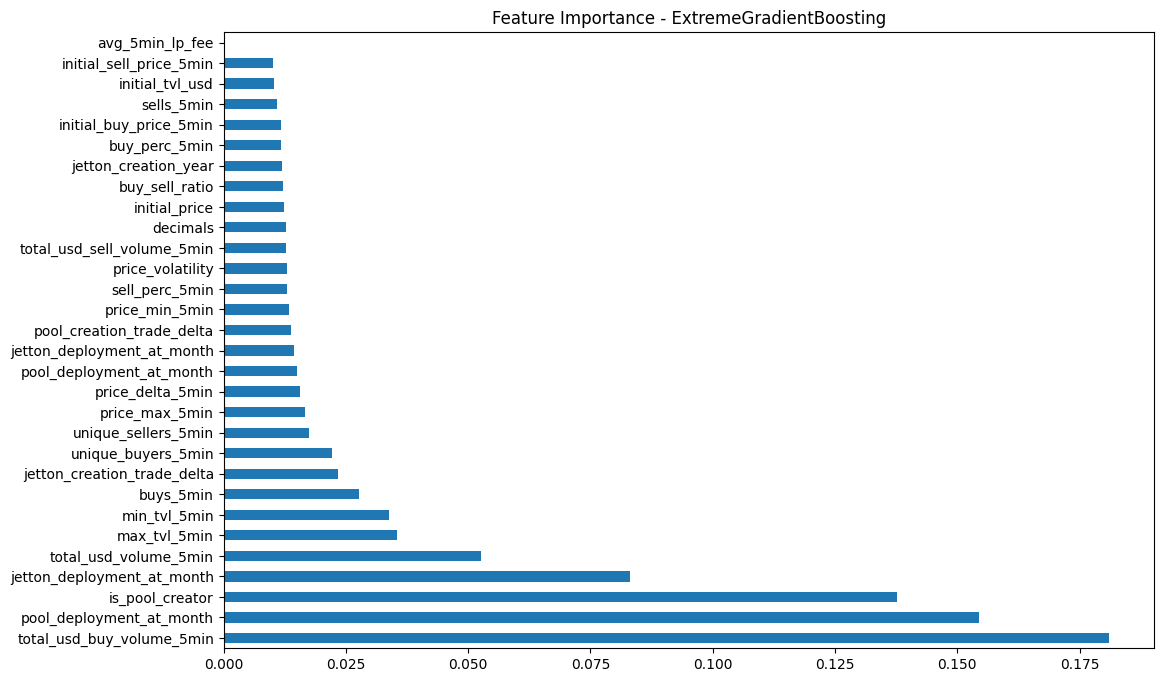

In [99]:
best_xgb = results['ExtremeGradientBoosting']['model']
importances = best_xgb.named_steps['classifier'].feature_importances_
# feature_names = numerical_features + categorical_features + cyclical_features + cyclical_features
feature_names = numerical_features + cyclical_features + cyclical_features

plt.figure(figsize=(12, 8))
pd.Series(importances, index=feature_names).nlargest(30).plot(kind='barh')
plt.title('Feature Importance - ExtremeGradientBoosting')
plt.show()

## preprocess

In [73]:
preprocessor.fit_transform(X).shape, X.shape

c:\Users\Димас\venvs\main_venv\lib\site-packages\sklearn\impute\_base.py:49: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode = stats.mode(array)
c:\Users\Димас\venvs\main_venv\lib\site-packages\sklearn\impute\_base.py:49: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warn

((33087, 31), (33087, 29))

In [74]:
preprocessor.fit_transform(X.iloc[0:2])

c:\Users\Димас\venvs\main_venv\lib\site-packages\sklearn\impute\_base.py:49: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode = stats.mode(array)
c:\Users\Димас\venvs\main_venv\lib\site-packages\sklearn\impute\_base.py:49: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warn

array([[ 6.00000000e+06,  6.28091805e-06,  6.00000000e+00,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
         3.00000000e+00,  0.00000000e+00,  1.06427728e+02,
         1.06427728e+02,  0.00000000e+00,  2.02400000e+03,
         9.00000000e+00,  3.20000000e-03,  8.00000000e-04,
         6.96000000e+02,  3.80000000e+02,  0.00000000e+00,
         2.36227263e+03,  9.56253395e-05,  9.56253395e-05,
         2.36227263e+03,  2.36227263e+03,  2.79076278e+06,
         1.01906257e-04,  9.56253395e-05,  0.00000000e+00,
         5.00000000e-01,  5.00000000e-01, -8.66025404e-01,
        -8.66025404e-01],
       [ 2.00000000e+06,  0.00000000e+00,  2.00000000e+00,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
         1.00000000e+00,  0.00000000e+00,  4.44679600e+00,
         4.44679600e+00,  0.00000000e+00,  2.02400000e+03,
         0.00000000e+00,  3.20000000e-03,  8.00000000e-04,
         2.54500000e+03,  8.77000000e+02,  0.00000000e+00,
         4.33833700e+00,  2.00

In [75]:
X.iloc[0:2]

,project,buy_sell_ratio,price_volatility,buys_5min,sells_5min,buy_perc_5min,sell_perc_5min,unique_buyers_5min,unique_sellers_5min,total_usd_volume_5min,...,initial_tvl_usd,initial_price,initial_buy_price,max_tvl_5min,min_tvl_5min,initial_sell_price,price_max_5min,price_min_5min,pool_deployment_at_month,jetton_deployment_at_month
66,dedust,6000000.0,0.000006,6,0,1.0,0.0,3,0,106.427728,...,2362.272625,9.562534e-05,9.562534e-05,2362.272625,2362.272625,NaN,1.019063e-04,9.562534e-05,5.0,5
67,dedust,2000000.0,0.000000,2,0,1.0,0.0,1,0,4.446796,...,4.338337,2.001953e+06,2.001953e+06,225.684180,225.684180,2.790763e+06,2.001953e+06,2.001953e+06,1.0,1


In [52]:
preprocessor

NameError: name 'preprocessor' is not defined

# Correlation

In [ ]:
stonfi_df[numerical_features + ['target']].corr()

,buy_sell_ratio,price_volatility,buys_5min,sells_5min,buy_perc_5min,sell_perc_5min,unique_buyers_5min,unique_sellers_5min,total_usd_volume_5min,total_usd_buy_volume_5min,...,initial_tvl_usd,initial_price,initial_buy_price_5min,max_tvl_5min,min_tvl_5min,initial_sell_price_5min,price_max_5min,price_min_5min,price_delta_5min,target
buy_sell_ratio,1.000000,-0.009924,0.028780,-0.103281,0.227187,-0.227187,0.026405,-0.102309,-0.035879,-0.019460,...,-0.015449,0.000129,0.000041,0.008017,0.030601,-0.007641,-0.009928,-0.006099,-0.003715,-0.021044
price_volatility,-0.009924,1.000000,-0.002436,-0.001869,-0.018710,0.018710,-0.002314,-0.001953,0.001324,0.002084,...,-0.001754,0.334479,0.334477,-0.001112,-0.001705,0.623567,1.000000,-0.000950,0.752121,0.004793
buys_5min,0.028780,-0.002436,1.000000,0.786223,-0.141633,0.141633,0.998417,0.779666,0.708746,0.593093,...,0.248451,-0.001344,-0.001386,0.085058,0.073356,-0.012374,-0.002440,-0.005969,-0.002066,-0.219577
sells_5min,-0.103281,-0.001869,0.786223,1.000000,-0.288788,0.288788,0.787899,0.990566,0.461058,0.353975,...,0.191120,-0.001640,-0.001659,0.037773,0.044372,-0.015029,-0.001872,-0.005748,-0.002758,-0.259882
buy_perc_5min,0.227187,-0.018710,-0.141633,-0.288788,1.000000,-1.000000,-0.144893,-0.281989,-0.089903,-0.055162,...,-0.064024,0.003271,0.003339,-0.009311,-0.018373,0.010253,-0.018717,-0.011158,-0.002461,0.137381
sell_perc_5min,-0.227187,0.018710,0.141633,0.288788,-1.000000,1.000000,0.144893,0.281989,0.089903,0.055162,...,0.064024,-0.003271,-0.003339,0.009311,0.018373,-0.010253,0.018717,0.011158,0.002461,-0.137381
unique_buyers_5min,0.026405,-0.002314,0.998417,0.787899,-0.144893,0.144893,1.000000,0.782672,0.707251,0.591784,...,0.244557,-0.001283,-0.001325,0.085507,0.074334,-0.012517,-0.002318,-0.006092,-0.002104,-0.219159
unique_sellers_5min,-0.102309,-0.001953,0.779666,0.990566,-0.281989,0.281989,0.782672,1.000000,0.458077,0.350621,...,0.195760,-0.001620,-0.001639,0.040322,0.047860,-0.014917,-0.001957,-0.005601,-0.002627,-0.255565
total_usd_volume_5min,-0.035879,0.001324,0.708746,0.461058,-0.089903,0.089903,0.707251,0.458077,1.000000,0.960117,...,0.273603,0.001548,0.001528,0.216971,0.158660,-0.006012,0.001322,-0.003185,0.000100,-0.140284
total_usd_buy_volume_5min,-0.019460,0.002084,0.593093,0.353975,-0.055162,0.055162,0.591784,0.350621,0.960117,1.000000,...,0.265656,0.002721,0.002705,0.231648,0.169056,-0.005052,0.002083,-0.002714,0.001029,-0.122272
